# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version — Multi-Seed SAC + Ablation Study (Calmar vs CVaR Reward) + XAI Analysis

In [26]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import Image, display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 2000
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False  # Set to False to just display in notebook

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'extra_features': [], 'is_ensemble': True},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

SCRIPT_DIR  = os.getcwd()
OUTPUT_DIR  = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')

Environment initialized.


## Data Loading

In [27]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets: {len(assets)}')
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()}')
print(f'Testing: {ret_test.index[0].date()} to {ret_test.index[-1].date()}')

Assets: 9
Training: 2017-09-15 to 2019-03-02
Testing: 2019-03-03 to 2019-10-17


## Portfolio Optimization Logic

In [28]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0

def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec

def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))

def compute_classic_mv_weights(returns_window):
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    return res.x if res.success else w0

## Metrics & Helpers

In [29]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return dd, cumulative

def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0

def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0

def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0

def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0

def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd**2)))

def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : max_dd,
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }

## Visualization Helpers

In [30]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF9800',
    'E2_Sortino'         : '#9C27B0',
    'E2_Calmar'          : '#2196F3',
    'E2_Ulcer'           : '#F44336',
    'E2_Ensemble_Avg'    : '#00BCD4',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#3F51B5',
}

DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'γ=0 (Static)',
    'Comp_Static_Gamma1' : 'γ=1 (Static)',
    'Comp_Static_Gamma2' : 'γ=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
}

def get_display_name(exp_id):
    return DISPLAY_NAMES.get(exp_id, exp_id)

FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend'
]

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.current_episode_reward = 0
    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0
        return True

def plot_learning_curves(history_dict):
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0: continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards)//10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves — Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150)
    plt.show()
    plt.close()

## Dashboard & Statistical Analysis

In [31]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    stats_summary = []
    if baseline_id not in results_dict: return "Baseline not found"
    baseline_rets = results_dict[baseline_id].mean(axis=1)
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id: continue
        exp_rets = rets_df.mean(axis=1)
        try:
            stat, p = stats.wilcoxon(exp_rets, baseline_rets)
            stats_summary.append(f"vs {exp_id}: p={p:.4f}")
        except: stats_summary.append(f"vs {exp_id}: error")
    return "\n ".join(stats_summary)

def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    exp_ids = list(results_dict.keys())
    metrics_list = []
    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        res = {'Experiment': exp_id, 'Features': 'Network(5) + Market(4)' if str(exp_id).startswith('E2') else 'Static/Baseline', 
               'Obs Dim': get_obs_dim(ABLATION_CONFIGS.get(exp_id, {})) if exp_id in ABLATION_CONFIGS else 0}
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std'] = np.std(vals)
        metrics_list.append(res)
    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)

    # --- Diagram 1: Table & Bar Charts ---
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1 = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(f'{title_prefix} — Metrics Comparison\nSteps: {TRAIN_STEPS}', fontsize=14, fontweight='bold', y=0.98)

    ax_table = fig1.add_subplot(gs1[0, :]); ax_table.axis('off')
    columns = ['Experiment', 'Features', 'Obs Dim', 'Sharpe (↑)', 'Sortino (↑)', 'Calmar (↑)', 'Ulcer (↓)', 'Rank']
    table_data = [[row['Experiment'], row['Features'], row['Obs Dim'], 
                   f"{row['Sharpe Ratio Mean']:.3f}±{row['Sharpe Ratio Std']:.3f}",
                   f"{row['Sortino Ratio Mean']:.3f}±{row['Sortino Ratio Std']:.3f}",
                   f"{row['Calmar Ratio Mean']:.3f}±{row['Calmar Ratio Std']:.3f}",
                   f"{row['Ulcer Index Mean']:.4f}±{row['Ulcer Index Std']:.4f}", f"#{i+1}"] for i, (_, row) in enumerate(df_metrics.iterrows())]
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 2)
    ax_table.set_title('Rangkuman Metrik Performa', fontsize=11, fontweight='bold', pad=15)

    for i, m in enumerate(EVAL_METRICS):
        ax = fig1.add_subplot(gs1[1, i])
        means = [row[f'{m} Mean'] for _, row in df_metrics.iterrows()]
        exps = [row['Experiment'] for _, row in df_metrics.iterrows()]
        ax.bar(exps, means, color=[ABLATION_COLORS.get(e, '#777777') for e in exps])
        ax.set_title(f'{m}', fontsize=10, fontweight='bold')
        ax.set_xticklabels([get_display_name(e) for e in exps], rotation=45, ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if SAVE_IMAGES: plt.savefig(os.path.join(OUTPUT_DIR, f"1_metrics_{filename_base}"), dpi=200)
    plt.show(); plt.close()

    # --- Diagram 2: Cumulative Returns ---
    plt.figure(figsize=(16, 7), facecolor='white')
    for exp_id in results_dict: 
        plt.plot((1 + results_dict[exp_id].mean(axis=1)).cumprod(), label=get_display_name(exp_id), color=ABLATION_COLORS.get(exp_id, '#777777'))
    plt.title(f'Cumulative Returns — {period_name} Period — Steps: {TRAIN_STEPS}', fontsize=14, fontweight='bold')
    plt.legend(); plt.grid(True, alpha=0.3)
    if SAVE_IMAGES: plt.savefig(os.path.join(OUTPUT_DIR, f"2_returns_{filename_base}"), dpi=200)
    plt.show(); plt.close()

## SHAP Interpretability Analysis

In [32]:
def plot_shap_analysis(model_paths, env, config, exp_id):
    print(f"Generating SHAP analysis for {exp_id}...")
    models = [SAC.load(p) for p in model_paths] if isinstance(model_paths, list) else [SAC.load(model_paths)]
    obs_list = []
    for _ in range(50): # Sample 50 steps for speed
        obs, _ = env.reset(); done = False
        while not done and len(obs_list) < 200:
            obs_list.append(obs)
            action, _ = models[0].predict(obs, deterministic=True)
            obs, _, done, _, _ = env.step(action)
    X = np.array(obs_list); df_X = pd.DataFrame(X, columns=FEATURE_NAMES[:X.shape[1]])
    
    def predict_action(x):
        x_torch = torch.tensor(np.array(x), dtype=torch.float32)
        with torch.no_grad():
            all_actions = [m.policy.actor(x_torch).numpy() for m in models]
            return np.mean(all_actions, axis=0)

    explainer = shap.Explainer(predict_action, df_X[:50])
    shap_values = explainer(df_X[50:150])
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, df_X[50:150], show=False)
    plt.title(f'SHAP Feature Importance — {exp_id} — Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    if SAVE_IMAGES: plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png'), dpi=150)
    plt.show(); plt.close()

## Feature Engineering & Cache

In [33]:
def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec

def compute_market_features(returns_window, port_val=0.0):
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5, v20 = arr[-win5:].std(axis=0).mean(), arr[-win20:].std(axis=0).mean()
    m5, m20 = arr[-win5:].mean(axis=0).mean(), arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([v5*100, v20*100, v5/(v20+1e-8), m5*100, m20*100, (m5-m20)*100, pct_up], dtype=np.float32)

GLOBAL_CACHE = {}
print('Precomputing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win = ret_train.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win = ret_test.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[len(ret_train)+i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

FEAT_MEAN = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).mean(axis=0)
FEAT_STD  = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).std(axis=0) + 1e-8

def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None: nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config['use_network']: obs.append((nw_feat_raw - FEAT_MEAN)/FEAT_STD)
    if config['use_market']:  obs.append(compute_market_features(win))
    return np.nan_to_num(np.concatenate(obs)), corr_f

def get_obs_dim(config):
    d = 0
    if config['use_network']: d += 2
    if config['use_market']:  d += 7
    return max(d, 1)

Precomputing cache...


  0%|          | 0/504 [00:00<?, ?it/s]

  0%|          | 0/199 [00:00<?, ?it/s]

## RL Environment

In [34]:
class AblationPortfolioEnv(gym.Env):
    def __init__(self, data, config, data_start_offset=0):
        super().__init__()
        self.data, self.config, self.offset = data, config, data_start_offset
        self.current_step = SET_WINDOW; self._returns_buffer = []
        self._rew_stats = {'mean': 0, 'M2': 0, 'count': 0}
        dim = get_obs_dim(config)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _get_obs(self):
        idx = self.offset + self.current_step; c = GLOBAL_CACHE[idx]
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step = SET_WINDOW; self._returns_buffer = []
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        idx = self.offset + self.current_step; c = GLOBAL_CACHE[idx]
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW: self._returns_buffer.pop(0)
        arr = np.array(self._returns_buffer); reward_type = self.config.get('reward_type', 'calmar')
        if len(arr) < 2: raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe': raw_reward = float(np.clip(calculate_sharpe_ratio(arr), -10.0, 10.0))
            elif reward_type == 'sortino': raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar': raw_reward = float(np.clip(calculate_calmar_ratio(arr), -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret, ulcer = calculate_annualized_return(arr), calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / ulcer if ulcer > 1e-8 else ann_ret / 1e-8, -10.0, 10.0))
            else: raw_reward = 0.0
        s = self._rew_stats; s['count'] += 1; d = raw_reward - s['mean']; s['mean'] += d / s['count']; s['M2'] += d * (raw_reward - s['mean'])
        std = np.sqrt(s['M2']/s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))
        self.current_step += 1; done = self.current_step >= len(self.data) - 1
        return self._get_obs() if not done else np.zeros(self.observation_space.shape), reward, done, False, {}

## Training

Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Seeds for E2_Sharpe:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds for E2_Sortino:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds for E2_Calmar:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds for E2_Ulcer:   0%|          | 0/3 [00:00<?, ?it/s]

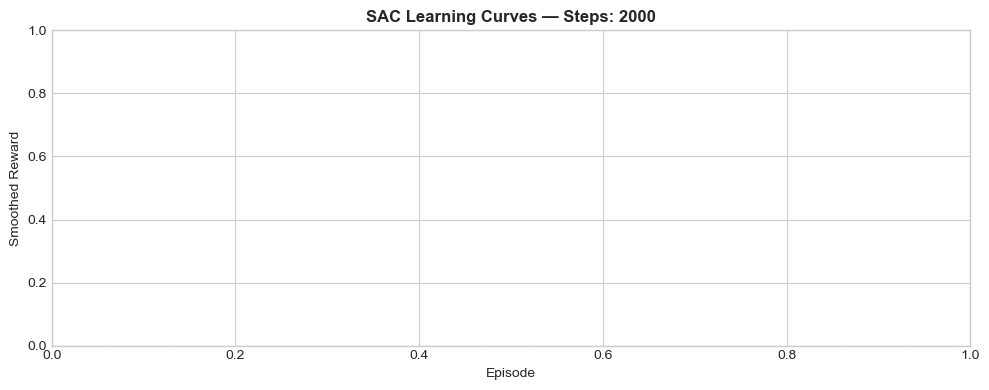

In [35]:
from tqdm.notebook import tqdm

trained_models = {}; train_histories = {}

# Loop utama eksperimen dengan progress bar
exp_bar = tqdm(ABLATION_CONFIGS.items(), desc="Experiments")
for exp_id, config in exp_bar:
    if config.get('static_gamma') is not None or config.get('is_ensemble'): continue
    
    train_histories[exp_id] = {}
    seed_bar = tqdm(SEEDS, desc=f"Seeds for {exp_id}", leave=False)
    
    for seed in seed_bar:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + ".zip"):
            trained_models[(exp_id, seed)] = name
            continue
            
        env = AblationPortfolioEnv(ret_train, config, 0)
        callback = RewardLoggerCallback()
        
        # Training dengan progress_bar bawaan SB3
        model = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)
        
        model.save(name)
        trained_models[(exp_id, seed)] = name
        train_histories[exp_id][seed] = callback.episode_rewards

if 'E2_Sharpe' in train_histories: plot_learning_curves(train_histories['E2_Sharpe'])

## Backtesting Loop

In [36]:
results_test = {}; results_train = {}
for exp_id in list(ABLATION_CONFIGS.keys()) + ['Classic-MV']:
    results_test[exp_id] = pd.DataFrame(); results_train[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})
    for seed in SEEDS:
        model = None; ensemble_models = []
        if exp_id not in ['Classic-MV'] and config.get('static_gamma') is None:
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']: ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else: model = SAC.load(trained_models[(exp_id, seed)])
        
        # Testing Re-run
        rets_test = []
        for i in range(SET_WINDOW, len(ret_test)):
            idx = len(ret_train) + i; c = GLOBAL_CACHE[idx]
            if exp_id == 'Classic-MV': w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None: w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            elif config.get('is_ensemble'):
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], sum(gammas)/len(gammas))
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            rets_test.append(np.dot(w, ret_test.iloc[i].values))
        results_test[exp_id][seed] = pd.Series(rets_test, index=ret_test.index[SET_WINDOW:])

        # Training Re-run
        rets_train_eval = []
        for i in range(SET_WINDOW, len(ret_train)):
            c = GLOBAL_CACHE[i]
            if exp_id == 'Classic-MV': w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None: w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            elif config.get('is_ensemble'):
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], sum(gammas)/len(gammas))
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            rets_train_eval.append(np.dot(w, ret_train.iloc[i].values))
        results_train[exp_id][seed] = pd.Series(rets_train_eval, index=ret_train.index[SET_WINDOW:])

## Final Analysis & SHAP


Generating Final Dashboards...


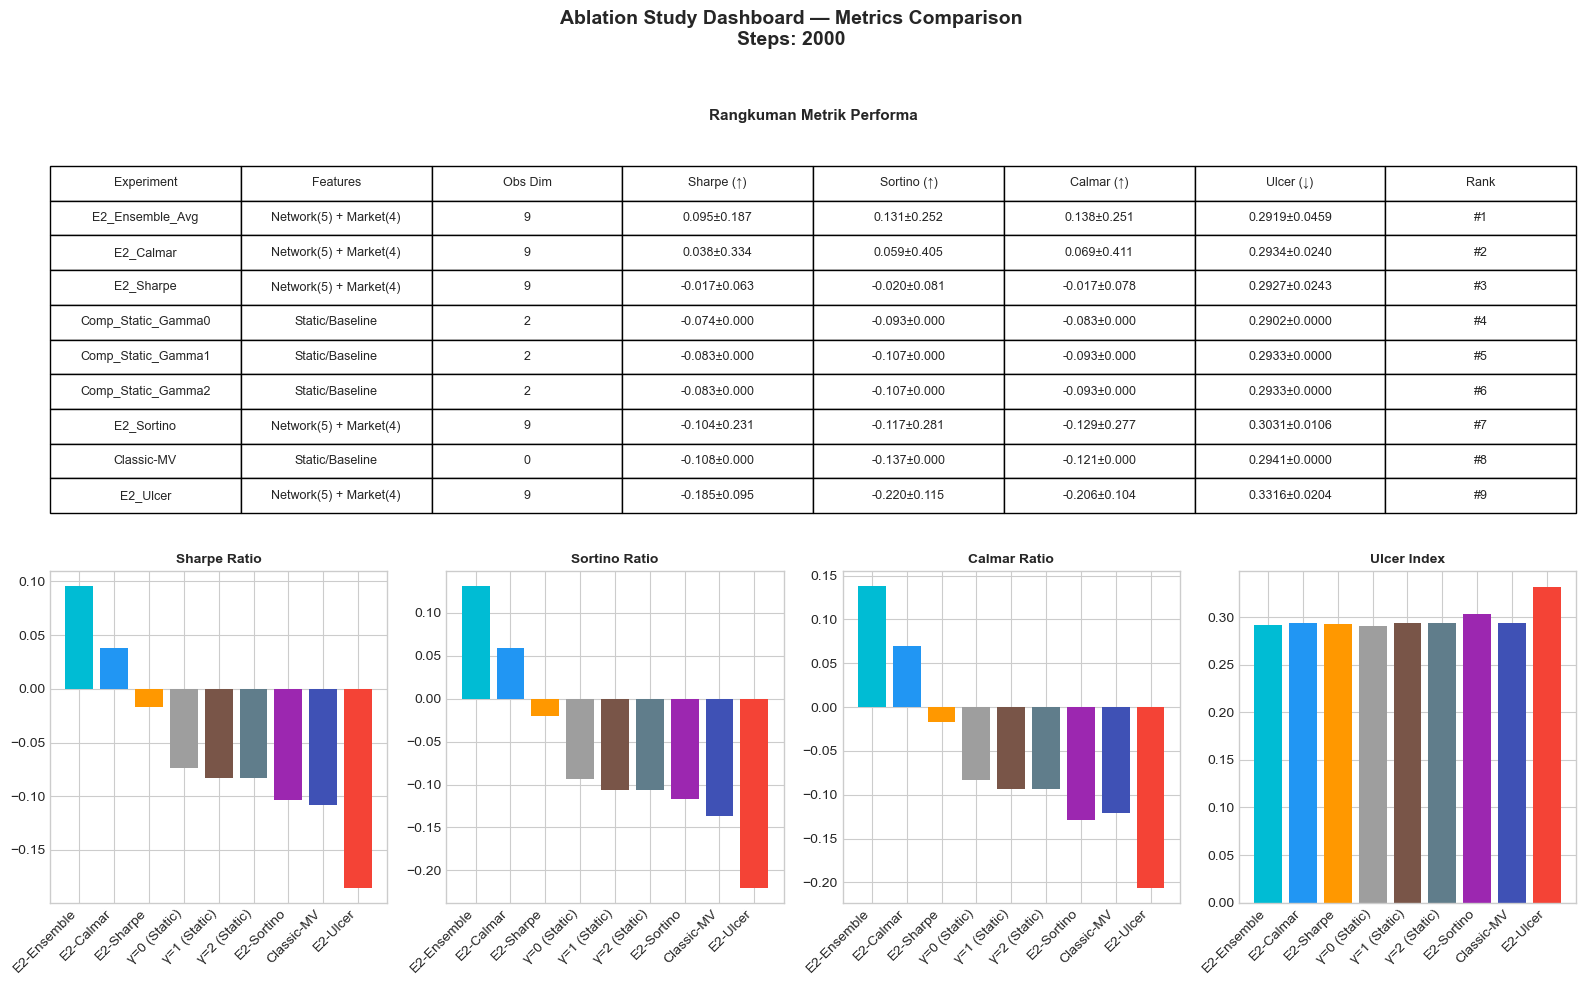

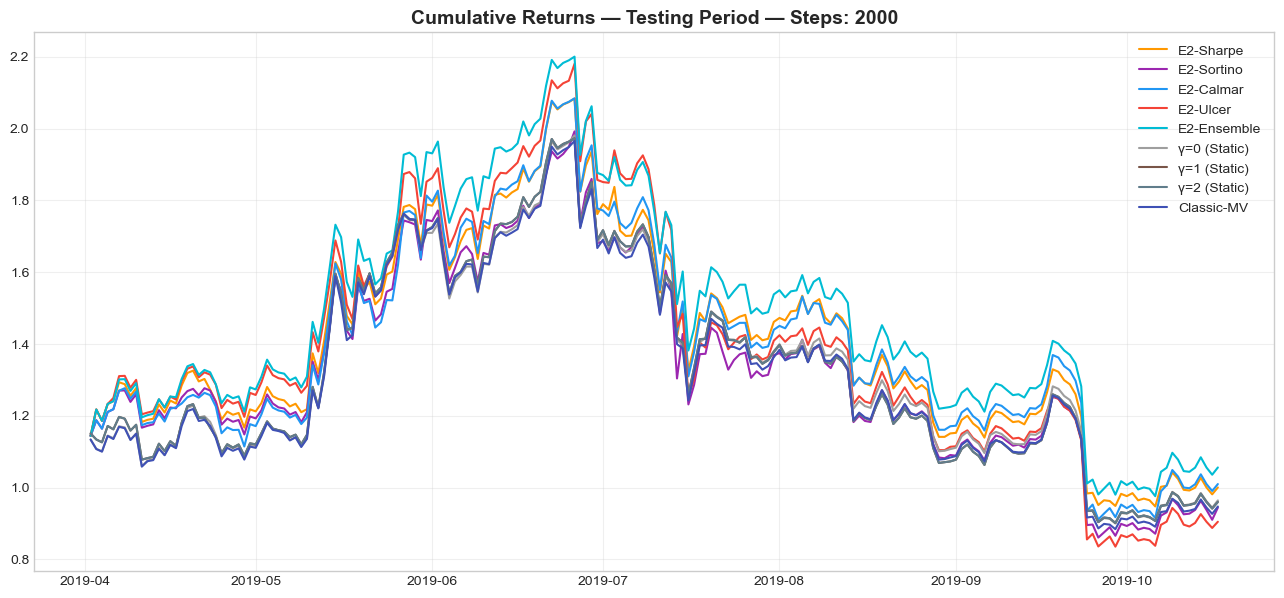

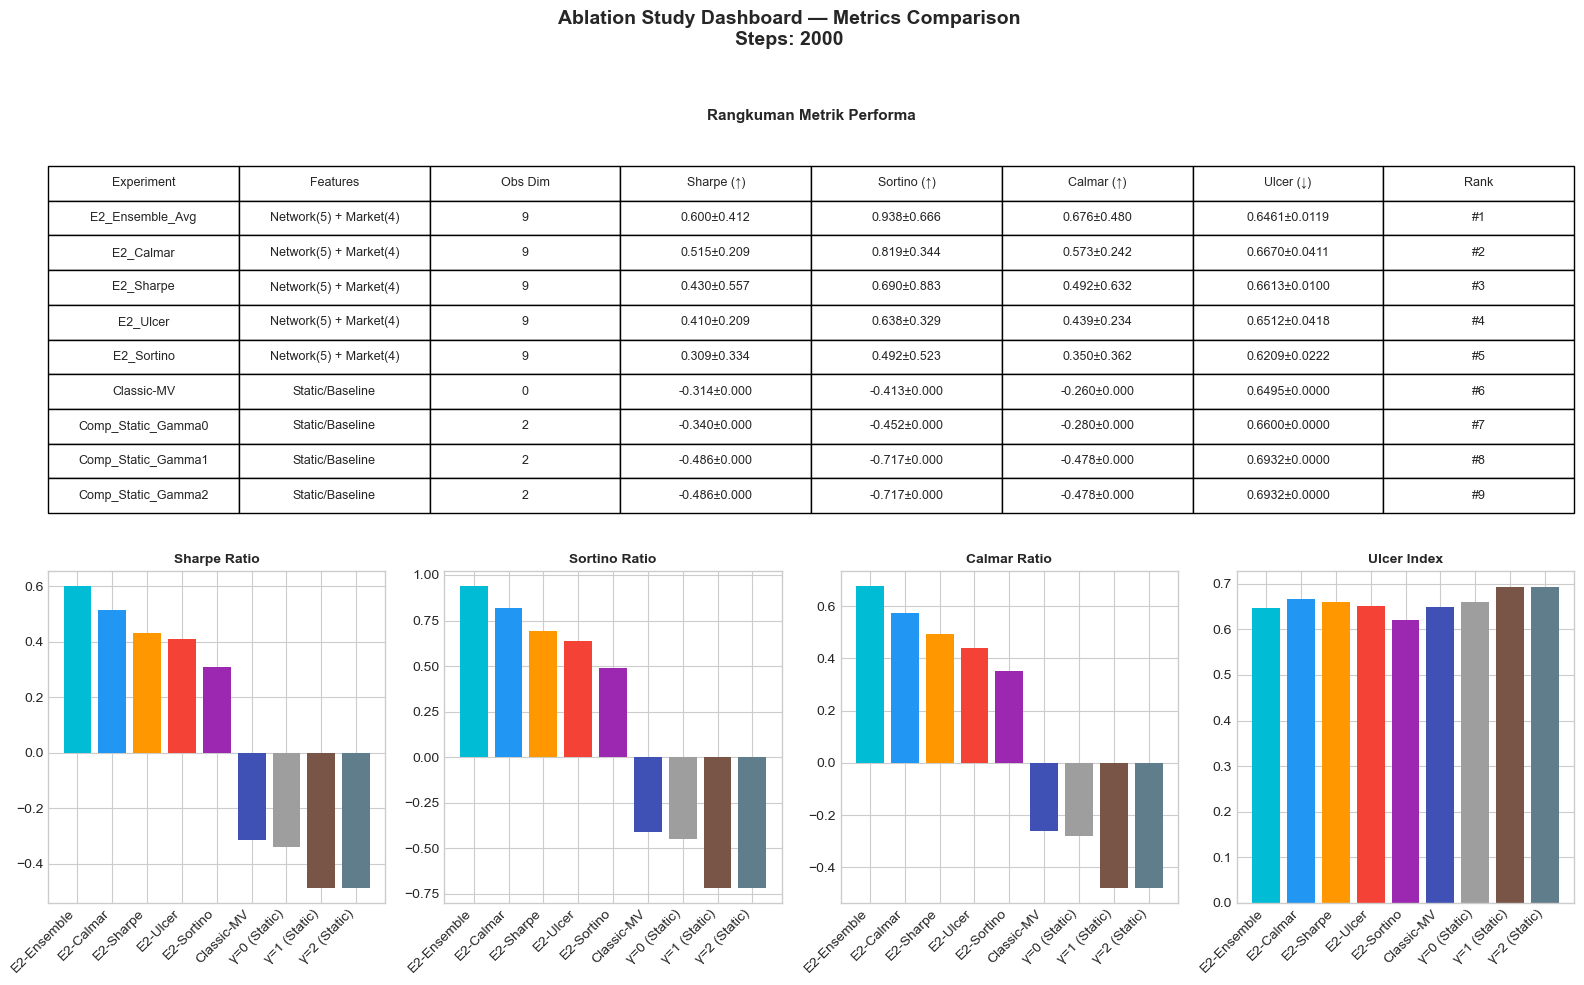

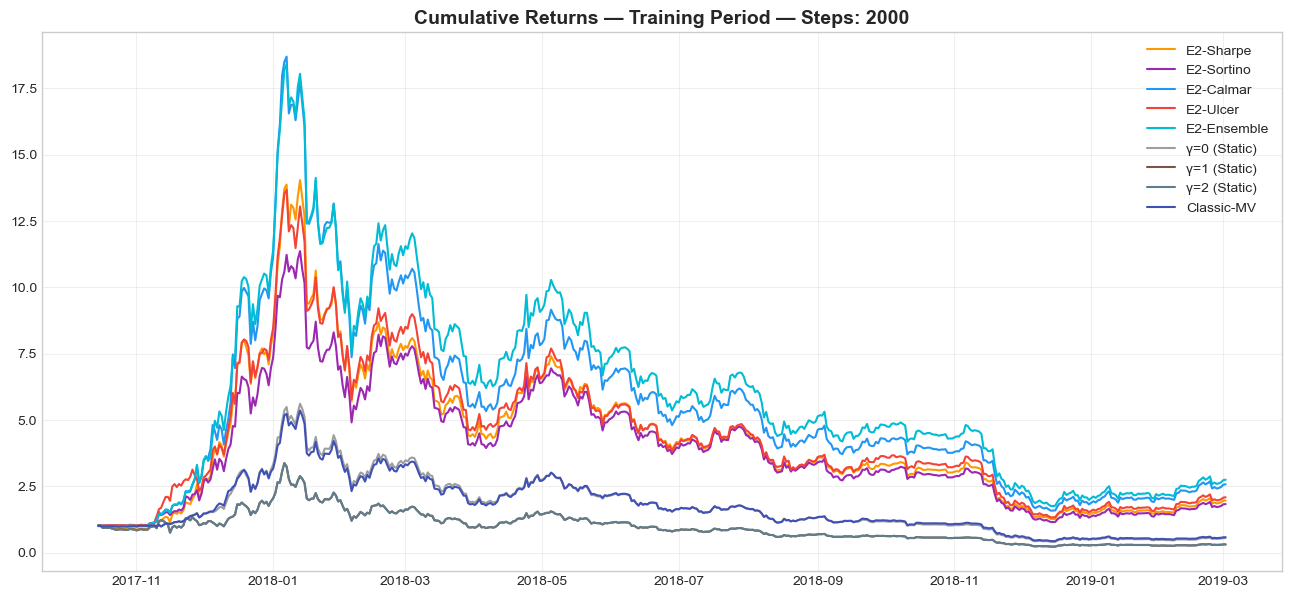


Generating SHAP analysis for all E2 models...
Generating SHAP analysis for E2_Sharpe...


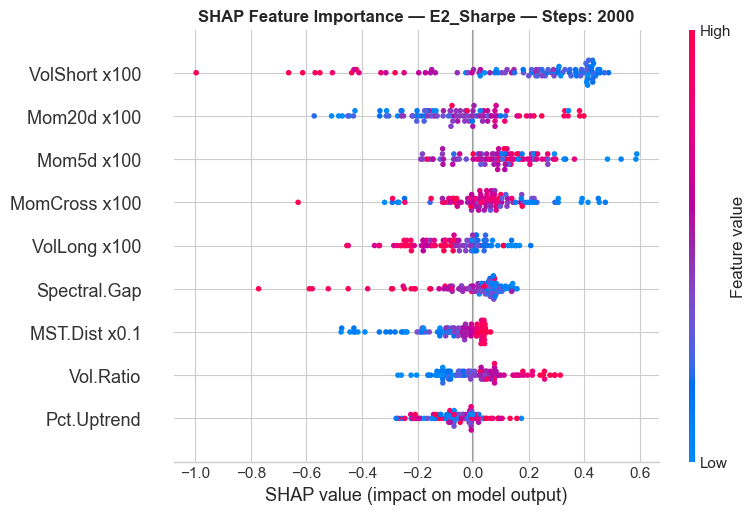

Generating SHAP analysis for E2_Sortino...


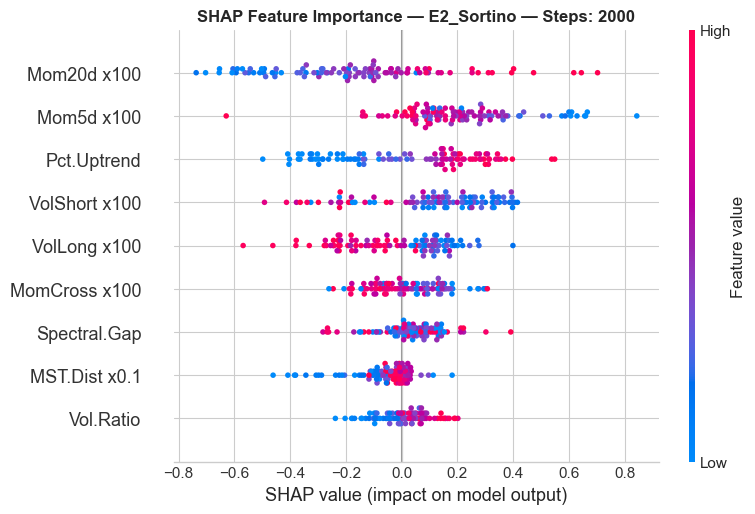

Generating SHAP analysis for E2_Calmar...


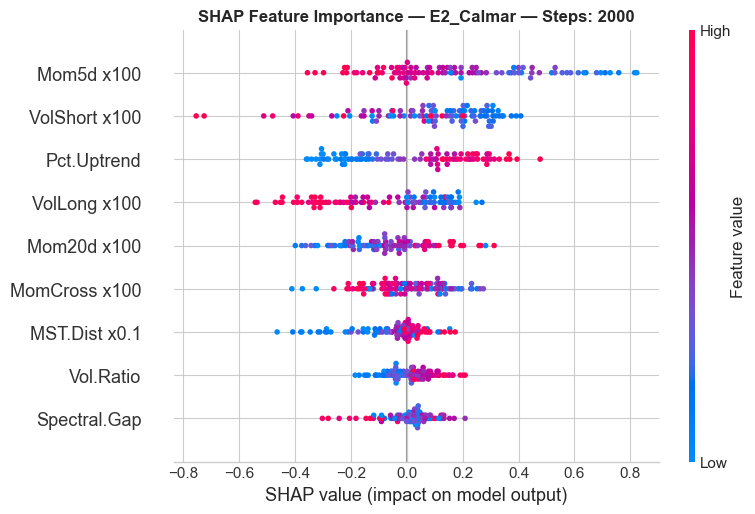

Generating SHAP analysis for E2_Ulcer...


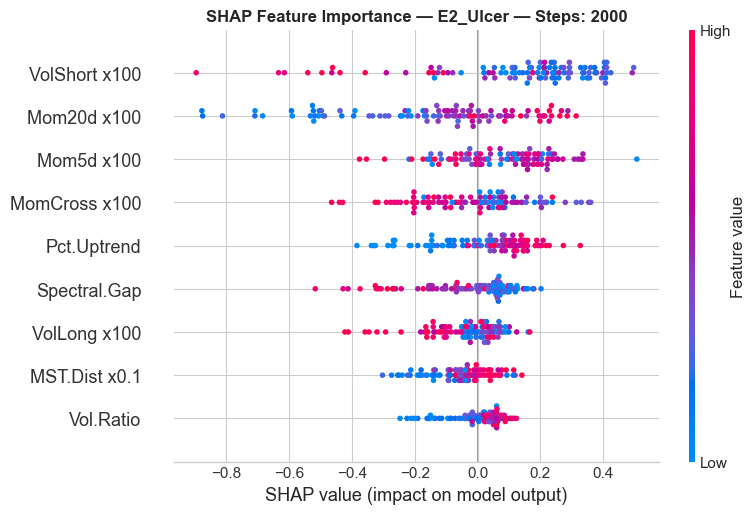

Generating SHAP analysis for E2_Ensemble_Avg...


ExactExplainer explainer: 101it [00:12,  1.63it/s]                         


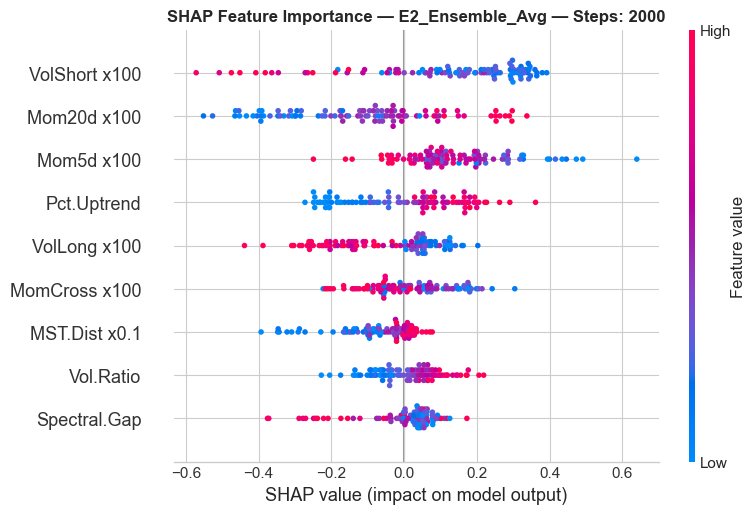

In [37]:
print("\nGenerating Final Dashboards...")
generate_dashboard(results_test, "Ablation Study Dashboard", "Testing", "testing.png")
generate_dashboard(results_train, "Ablation Study Dashboard", "Training", "training.png")

print("\nGenerating SHAP analysis for all E2 models...")
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    if exp_id == 'E2_Ensemble_Avg':
        m_paths = [trained_models.get((m, seed0)) for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
    else: m_paths = trained_models.get((exp_id, seed0))
    if m_paths is not None: plot_shap_analysis(m_paths, AblationPortfolioEnv(ret_test, config, len(ret_train)), config, exp_id)